# Object Detection with YOLOv8 on Pascal VOC 2012


This notebook trains two YOLOv8m detectors on a 5-class subset of Pascal VOC 2012. One with full augmentation (Model A) and one without (Model B), then evaluates both overall and by object size.

## A. Setup

In [1]:
!pip install ultralytics roboflow pyyaml -q
import ultralytics, yaml
print('Ultralytics:', ultralytics.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/redsteam/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.31


## B. Download and Prepare Dataset

Download Pascal VOC 2012 from Roboflow, filter to 5 classes (cat, horse, car, dog, bird), remap class IDs, and remove images with no relevant objects.

In [2]:
import requests, zipfile, os
from tqdm import tqdm

url = 'https://public.roboflow.com/ds/MDGNWrCzdb?key=wqBgW4vtSG'
download_dir = 'data/voc_dataset'
zip_path = download_dir + '/dataset.zip'
os.makedirs(download_dir, exist_ok=True)

response   = requests.get(url, stream=True)
total_size = int(response.headers.get('content-length', 0))
with open(zip_path, 'wb') as f, tqdm(total=total_size, unit='B', unit_scale=True) as bar:
    for chunk in response.iter_content(chunk_size=1024):
        f.write(chunk); bar.update(len(chunk))

with zipfile.ZipFile(zip_path) as z:
    z.extractall(download_dir)
print('Done.')

100%|██████████| 623M/623M [01:21<00:00, 7.66MB/s]   


Done.


In [4]:
import yaml
from pathlib import Path

DATA_YAML = next(
    os.path.join(r, 'data.yaml')
    for r, _, fs in os.walk(download_dir) if 'data.yaml' in fs
)
with open(DATA_YAML) as f:
    config = yaml.safe_load(f)

base_dir = os.path.dirname(DATA_YAML)
print('Classes:', config['names'])

Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [5]:
TARGET_CLASSES = ['cat', 'horse', 'car', 'dog', 'bird']

name_to_id  = {n: i for i, n in enumerate(config['names'])}
selected_ids = [name_to_id[n] for n in TARGET_CLASSES]
id_mapping = {old: new for new, old in enumerate(selected_ids)}

def filter_labels(label_dir):
    for lf in Path(label_dir).glob('*.txt'):
        kept = []
        for line in open(lf):
            p = line.strip().split()
            if len(p) >= 5 and int(p[0]) in selected_ids:
                kept.append(str(id_mapping[int(p[0])]) + ' ' + ' '.join(p[1:]))
        open(lf, 'w').write('\n'.join(kept) + ('\n' if kept else ''))

def remove_empty(split):
    for lf in (Path(base_dir) / split / 'labels').glob('*.txt'):
        if os.path.getsize(lf) == 0:
            img = Path(base_dir) / split / 'images' / (lf.stem + '.jpg')
            if img.exists(): os.remove(img)
            os.remove(lf)

for split in ['train', 'valid', 'test']:
    if (Path(base_dir) / split / 'labels').exists():
        filter_labels(Path(base_dir) / split / 'labels')
        remove_empty(split)

config['names'] = TARGET_CLASSES
config['nc'] = len(TARGET_CLASSES)
yaml.dump(config, open(DATA_YAML, 'w'))

for split in ['train', 'valid']:
    imgs = len(list((Path(base_dir) / split / 'images').glob('*')))
    lbls = len(list((Path(base_dir) / split / 'labels').glob('*.txt')))
    print(f'{split.upper():<6}  images={imgs}  labels={lbls}')

TRAIN   images=3948  labels=3948
VALID   images=1020  labels=1020


## C. Exploratory Data Analysis

### C1. Class distribution

class  instances
  car       1988
  dog       1234
 bird       1056
  cat       1034
horse        611


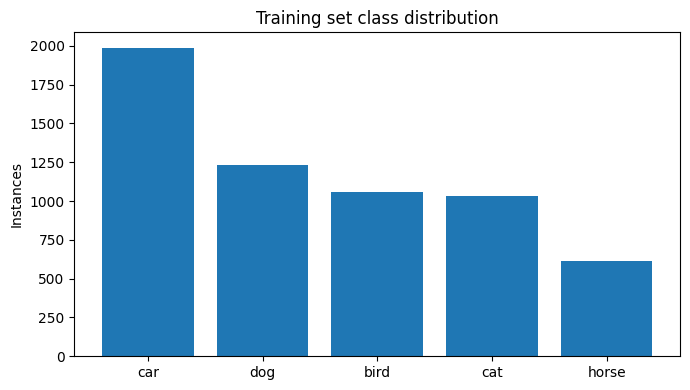

In [6]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

counts = Counter()
for lf in (Path(base_dir) / 'train' / 'labels').glob('*.txt'):
    for line in open(lf):
        p = line.strip().split()
        if len(p) >= 5: counts[int(p[0])] += 1

df_counts = pd.DataFrame({
    'class': [TARGET_CLASSES[i] for i in sorted(counts)],
    'instances': [counts[i] for i in sorted(counts)]
}).sort_values('instances', ascending=False).reset_index(drop=True)
print(df_counts.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(df_counts['class'], df_counts['instances'])
plt.ylabel('Instances'); plt.title('Training set class distribution')
plt.tight_layout()
plt.savefig('content/class_dist.png', dpi=180, bbox_inches='tight')
plt.show()

### C2. Object size distribution

Using COCO thresholds: Small < 32×32 px², Medium 32–96 px², Large > 96×96 px².

Train: {'Small (<32x32 px)': 309, 'Medium (32-96 px)': 1128, 'Large (>96x96 px)': 4486}
Val:  {'Small (<32x32 px)': 43, 'Medium (32-96 px)': 278, 'Large (>96x96 px)': 1196}


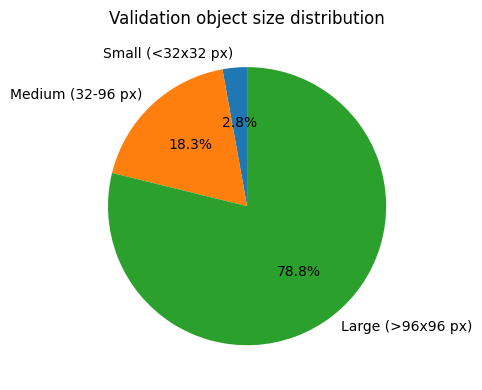

In [7]:
def analyse_sizes(label_dir, img_size=640):
    counts = {'Small (<32x32 px)': 0, 'Medium (32-96 px)': 0, 'Large (>96x96 px)': 0}
    for lf in Path(label_dir).glob('*.txt'):
        for line in open(lf):
            p = line.strip().split()
            if len(p) < 5:
                continue
            area = float(p[3]) * img_size * float(p[4]) * img_size
            if   area < 1024:
                counts['Small (<32x32 px)']  += 1
            elif area < 9216:
                counts['Medium (32-96 px)']  += 1
            else:
                counts['Large (>96x96 px)']  += 1
    return counts

size_counts_train = analyse_sizes(Path(base_dir) / 'train' / 'labels')
size_counts_val = analyse_sizes(Path(base_dir) / 'valid' / 'labels')

print('Train:', size_counts_train)
print('Val: ', size_counts_val)

plt.figure(figsize=(5, 4))
plt.pie(size_counts_val.values(), labels=size_counts_val.keys(),
        autopct='%1.1f%%', startangle=90)
plt.title('Validation object size distribution')
plt.tight_layout()
plt.savefig('content/val_obj_size_dist.png', dpi=180, bbox_inches='tight')
plt.show()

### C3. Sample training images

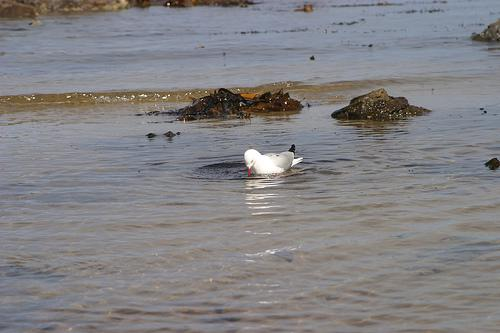

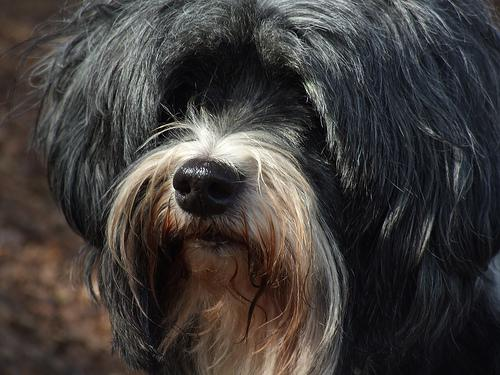

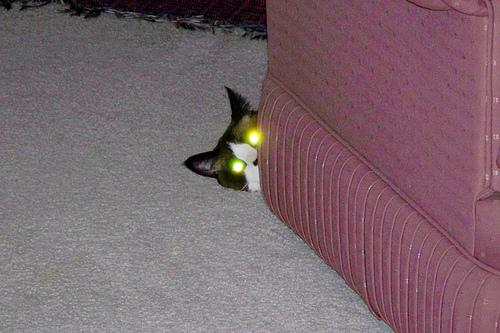

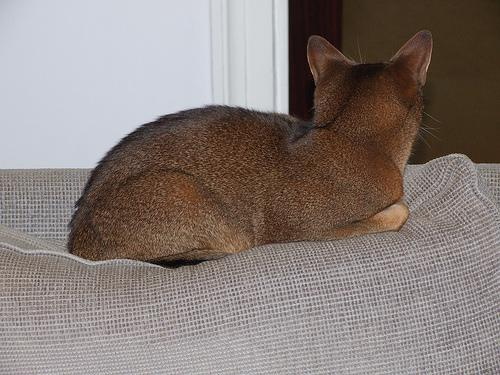

In [8]:
import random
from IPython.display import Image, display

samples = random.sample(list((Path(base_dir) / 'train' / 'images').glob('*')), 4)
for img in samples:
    display(Image(filename=str(img), width=480))

## D. Model Training

Both models use YOLOv8m pre-trained on COCO, fine-tuned for 20 epochs on our 5-class subset. The **only** difference is the augmentation configuration.

### D1. Model B — No augmentation (baseline)

In [ ]:
from ultralytics import YOLO

model_b = YOLO('yolov8m.pt')
model_b.train(
    data=DATA_YAML, epochs=20, imgsz=640, batch=16,
    name='voc_no_aug', device=0, patience=15, plots=True,
    mosaic=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, fliplr=0.0,
    verbose=True
)

### D2. Model A — Full augmentation

In [ ]:
model_a = YOLO('yolov8m.pt')
model_a.train(
    data=DATA_YAML, epochs=20, imgsz=640, batch=16,
    name='voc_full_aug', device=0, patience=15, plots=True,
    mosaic=1.0, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, fliplr=0.5,
    verbose=True
)

## E. Evaluation

### E1. Overall metrics — Model A vs Model B

In [10]:
from ultralytics import YOLO
import pandas as pd

model_a = YOLO('content/runs/detect/voc_full_aug/weights/best.pt')
model_b = YOLO('content/runs/detect/voc_no_aug/weights/best.pt')

metrics_a = model_a.val(data=DATA_YAML, name='eval_a', verbose=False)
metrics_b = model_b.val(data=DATA_YAML, name='eval_b', verbose=False)

ma50, ma5095, mprec, mrec = metrics_a.box.map50, metrics_a.box.map, metrics_a.box.mp, metrics_a.box.mr
mb50, mb5095, mbprec, mbrec = metrics_b.box.map50, metrics_b.box.map, metrics_b.box.mp, metrics_b.box.mr

df_cmp = pd.DataFrame({
    'Metric': ['mAP@50', 'mAP@50:95', 'Precision', 'Recall'],
    'Model A (aug ON)': [round(v, 4) for v in [ma50, ma5095, mprec, mrec]],
    'Model B (aug OFF)':[round(v, 4) for v in [mb50, mb5095, mbprec, mbrec]],
})
df_cmp['Δ (A−B)'] = (df_cmp['Model A (aug ON)'] - df_cmp['Model B (aug OFF)']).round(4)
print(df_cmp.to_string(index=False))
df_cmp.to_csv('content/results_comparison.csv', index=False)

Ultralytics 8.4.31 🚀 Python-3.12.3 torch-2.9.0+cu128 CPU (Intel Core i7-8565U 1.80GHz)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 407.2±86.6 MB/s, size: 29.6 KB)
val: Scanning /home/redsteam/Downloads/Final_test_Group_10/data/voc_dataset/valid/labels... 1020 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1020/1020 1.0Kit/s 1.0s1ss
val: New cache created: /home/redsteam/Downloads/Final_test_Group_10/data/voc_dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 9.5s/it 10:109.3s
                   all       1020       1517      0.815      0.721      0.801      0.609
Speed: 1.7ms preprocess, 571.8ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /home/redsteam/Downloads/Final_test_Group_10/runs/detect/eval_a
Ultralytics 8.4.31 🚀 Python-3.12.3 torch-2.9.0+cu128 CPU (Intel Core i7-8565U 1.80

### E2. Per-class AP (Model A)

In [8]:
class_names = list(metrics_a.names.values())
ap50_values = [round(float(v), 4) for v in metrics_a.box.ap50]

df_classes = pd.DataFrame({'Class': class_names, 'AP@50': ap50_values})\
    .sort_values('AP@50', ascending=False).reset_index(drop=True)
df_classes.index += 1
print(df_classes)
df_classes.to_csv('content/perclass_ap.csv', index=False)

s_names = df_classes['Class'].tolist()
s_vals  = df_classes['AP@50'].tolist()

   Class   AP@50
1    cat  0.8689
2    dog  0.8162
3  horse  0.8099
4    car  0.7964
5   bird  0.7133


### E3. Diagnostic plots

In [9]:
from IPython.display import Image, display

metrics_plots = model_a.val(data=DATA_YAML, plots=True, name='full_eval', verbose=False)
plot_dir = 'content/runs/detect/full_eval/'

for fname in ['confusion_matrix.png', 'BoxPR_curve.png', 'BoxF1_curve.png']:
    path = plot_dir + fname
    if os.path.exists(path):
        print(fname)
        display(Image(filename=path, width=700))

Ultralytics 8.4.30 🚀 Python-3.10.20 torch-2.11.0+cu130 CPU (Intel Core Ultra 7 265H)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1807.1±410.8 MB/s, size: 40.6 KB)
val: Scanning /home/guest/Downloads/final_test/data/voc_dataset/valid/labels.cache... 1020 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1020/1020 133.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 2.8s/it 2:592.7ss
                   all       1020       1517      0.814      0.721      0.801      0.608
Speed: 0.3ms preprocess, 171.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/guest/Downloads/final_test/runs/detect/full_eval


### E4. Visualisation — comparison and per-class charts

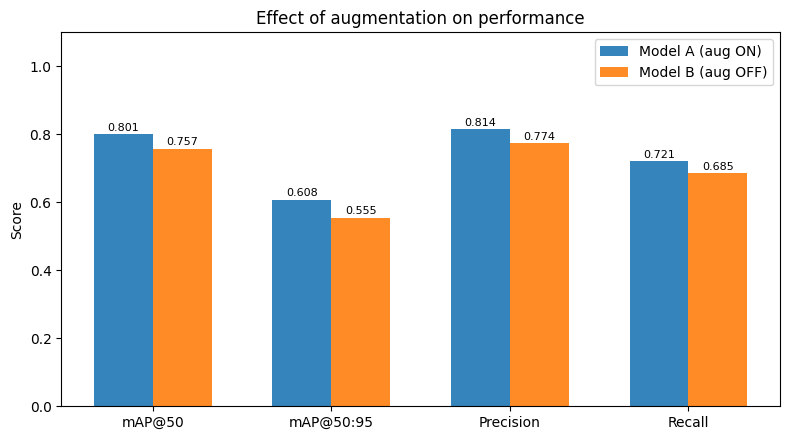

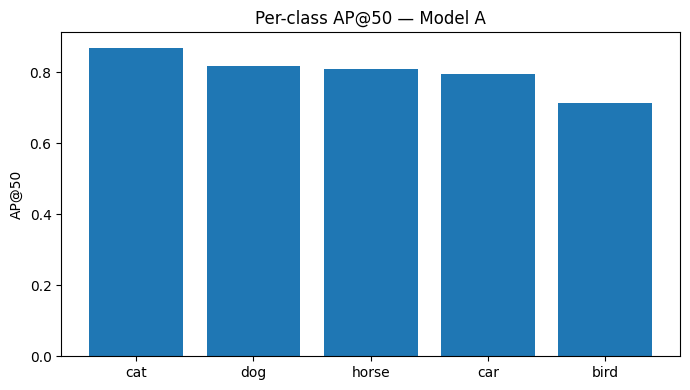

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Model A vs B bar chart
labels = ['mAP@50', 'mAP@50:95', 'Precision', 'Recall']
vals_a = [ma50, ma5095, mprec, mrec]
vals_b = [mb50, mb5095, mbprec, mbrec]
x, w   = np.arange(4), 0.33

fig, ax = plt.subplots(figsize=(8, 4.5))
ba = ax.bar(x - w/2, vals_a, w, label='Model A (aug ON)',  alpha=0.9)
bb = ax.bar(x + w/2, vals_b, w, label='Model B (aug OFF)', alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Effect of augmentation on performance'); ax.legend()
for bar in list(ba) + list(bb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('content/model_comparison_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

# Per-class AP chart
plt.figure(figsize=(7, 4))
plt.bar(s_names, s_vals)
plt.ylabel('AP@50'); plt.title('Per-class AP@50 — Model A')
plt.tight_layout()
plt.savefig('content/fig2_perclass.png', dpi=180, bbox_inches='tight')
plt.show()

## F. Small vs Large Object Analysis

We also evaluate performance under different conditions. Here we measure how well each model detects **small**, **medium**, and **large** objects separately, using the same COCO size thresholds as before.

We evaluate by collecting all predictions on the validation set, then scoring each prediction only against ground-truth boxes that fall into the target size bucket (IoU ≥ 0.5).

In [11]:
from ultralytics import YOLO
from pathlib import Path
import numpy as np, pandas as pd

IMG_SIZE = 640
SMALL_MAX = 32 ** 2
MEDIUM_MAX = 96 ** 2

def size_bucket(area):
    if   area < SMALL_MAX:
        return 'Small (<32x32)'
    elif area < MEDIUM_MAX:
        return 'Medium (32-96px)'
    else:
        return 'Large (>96x96)'

def eval_by_size(model_path, label_dir, img_dir, conf=0.25, iou_thr=0.5):
    model = YOLO(model_path)
    label_dir = Path(label_dir)
    img_dir = Path(img_dir)

    # Load all ground-truth boxes with size labels
    gt = {}  # stem → list of (cls, cx, cy, w, h, bucket)
    for lf in label_dir.glob('*.txt'):
        boxes = []
        for line in open(lf):
            p = line.strip().split()
            if len(p) < 5: continue
            w_px = float(p[3]) * IMG_SIZE
            h_px = float(p[4]) * IMG_SIZE
            boxes.append((int(p[0]),
                          float(p[1]) * IMG_SIZE, float(p[2]) * IMG_SIZE,
                          w_px, h_px,
                          size_bucket(w_px * h_px)))
        gt[lf.stem] = boxes

    buckets    = ['Small (<32x32)', 'Medium (32-96px)', 'Large (>96x96)']
    tp = {b: 0 for b in buckets}
    fp = {b: 0 for b in buckets}
    fn = {b: 0 for b in buckets}

    preds = model.predict(source=str(img_dir), conf=conf,
                          iou=0.45, save=False, verbose=False)

    for pred in preds:
        stem = Path(pred.path).stem
        gt_boxes = gt.get(stem, [])

        # count GT per bucket for this image
        for b in buckets:
            fn[b] += sum(1 for g in gt_boxes if g[5] == b)

        if pred.boxes is None or len(pred.boxes) == 0:
            continue

        matched = set()
        for box in pred.boxes:
            cls_p = int(box.cls[0])
            bx, by, bw, bh = [float(v) for v in box.xywh[0]]
            best_iou, best_i, best_b = 0, -1, None

            for gi, (gc, gcx, gcy, gw, gh, gb) in enumerate(gt_boxes):
                if gc != cls_p or gi in matched: continue
                ix1 = max(bx - bw/2, gcx - gw/2)
                iy1 = max(by - bh/2, gcy - gh/2)
                ix2 = min(bx + bw/2, gcx + gw/2)
                iy2 = min(by + bh/2, gcy + gh/2)
                inter = max(0, ix2-ix1) * max(0, iy2-iy1)
                union = bw*bh + gw*gh - inter
                iou   = inter / union if union > 0 else 0
                if iou > best_iou:
                    best_iou, best_i, best_b = iou, gi, gb

            if best_iou >= iou_thr:
                tp[best_b]  += 1
                fn[best_b]  -= 1
                matched.add(best_i)
            else:
                # assign FP to the closest GT bucket (or Large if no GT)
                fp[best_b if best_b else 'Large (>96x96)'] += 1

    rows = []
    for b in buckets:
        p  = tp[b] / (tp[b] + fp[b]) if (tp[b] + fp[b]) > 0 else 0
        r  = tp[b] / (tp[b] + fn[b]) if (tp[b] + fn[b]) > 0 else 0
        f1 = 2*p*r / (p+r) if (p+r) > 0 else 0
        rows.append({'Bucket': b, 'TP': tp[b], 'FP': fp[b], 'FN': fn[b],
                     'Precision': round(p,4), 'Recall': round(r,4), 'F1': round(f1,4)})
    return rows

val_imgs = os.path.join(base_dir, 'valid', 'images')
val_lbls = os.path.join(base_dir, 'valid', 'labels')

print('Evaluating Model A by size...')
res_a = eval_by_size('content/runs/detect/voc_full_aug/weights/best.pt', val_lbls, val_imgs)

print('Evaluating Model B by size...')
res_b = eval_by_size('content/runs/detect/voc_no_aug/weights/best.pt',  val_lbls, val_imgs)

Evaluating Model A by size...
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Evaluating Model B by size...
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs

In [12]:
# Summary table
rows = []
for a, b in zip(res_a, res_b):
    rows.append({
        'Size Bucket': a['Bucket'],
        'GT objects': a['TP'] + a['FN'],
        'A — Precision': a['Precision'],
        'A — Recall': a['Recall'],
        'A — F1': a['F1'],
        'B — Precision':  b['Precision'],
        'B — Recall': b['Recall'],
        'B — F1': b['F1'],
    })

df_size = pd.DataFrame(rows)
print(df_size.to_string(index=False))
df_size.to_csv('content/size_performance.csv', index=False)

     Size Bucket  GT objects  A — Precision  A — Recall  A — F1  B — Precision  B — Recall  B — F1
  Small (<32x32)          43         0.0000      0.0000  0.0000          0.000      0.0000  0.0000
Medium (32-96px)         278         0.0000      0.0000  0.0000          0.000      0.0000  0.0000
  Large (>96x96)        1196         0.0179      0.0217  0.0196          0.022      0.0268  0.0241


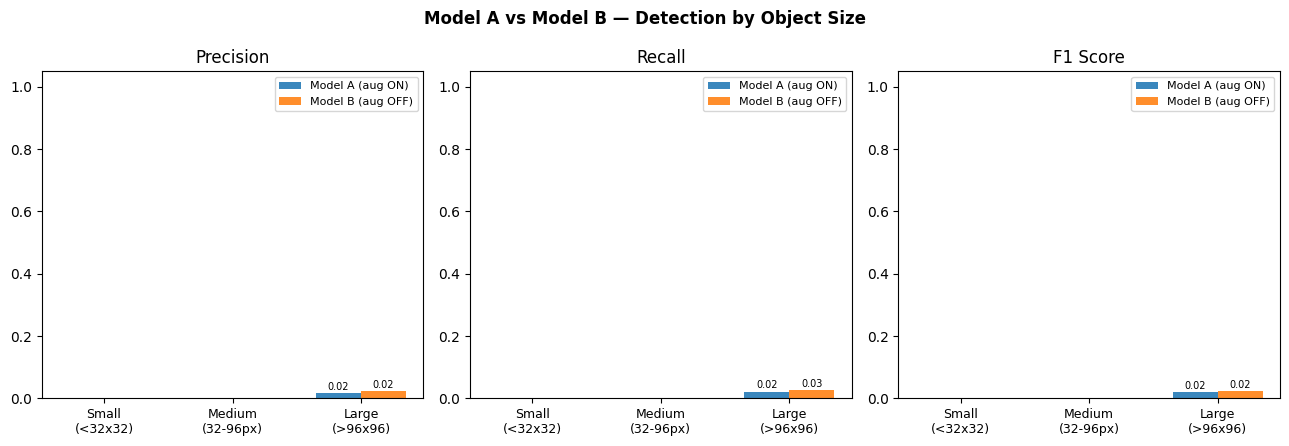

In [13]:
import matplotlib.pyplot as plt
import numpy as np

buckets = [r['Bucket'] for r in res_a]
short = ['Small\n(<32x32)', 'Medium\n(32-96px)', 'Large\n(>96x96)']
x, w = np.arange(3), 0.35

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
metrics_plot = [('Precision', 'Precision'), ('Recall', 'Recall'), ('F1', 'F1 Score')]

for ax, (key, title) in zip(axes, metrics_plot):
    va = [r[key] for r in res_a]
    vb = [r[key] for r in res_b]
    ba = ax.bar(x - w/2, va, w, label='Model A (aug ON)',  alpha=0.88)
    bb = ax.bar(x + w/2, vb, w, label='Model B (aug OFF)', alpha=0.88)
    ax.set_xticks(x); ax.set_xticklabels(short, fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_title(title); ax.legend(fontsize=8)
    for bar in list(ba) + list(bb):
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', fontsize=7)

plt.suptitle('Model A vs Model B — Detection by Object Size', fontweight='bold')
plt.tight_layout()
plt.savefig('content/fig_size_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

## G. Inference Examples

Run Model A on 8 validation images at confidence threshold 0.25 and display annotated results.


0: 640x640 1 bird, 177.1ms
1: 640x640 1 cat, 177.1ms
2: 640x640 1 cat, 177.1ms
3: 640x640 1 car, 177.1ms
4: 640x640 1 cat, 177.1ms
5: 640x640 1 cat, 177.1ms
6: 640x640 1 horse, 177.1ms
7: 640x640 1 dog, 1 bird, 177.1ms
Speed: 1.6ms preprocess, 177.1ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /home/guest/Downloads/final_test/runs/detect/predictions


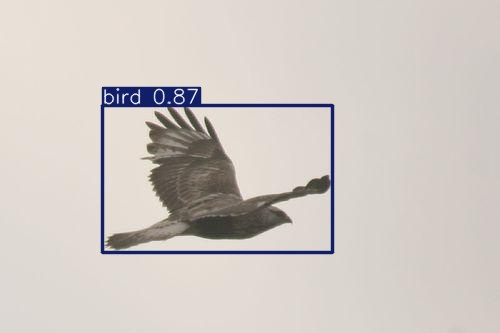

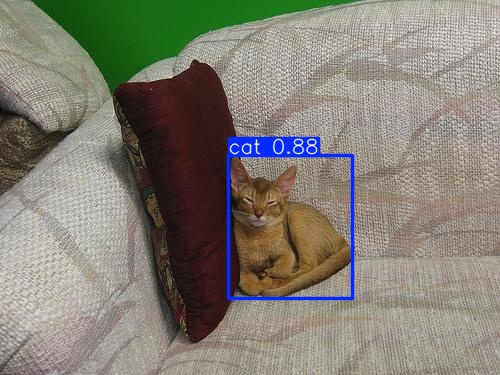

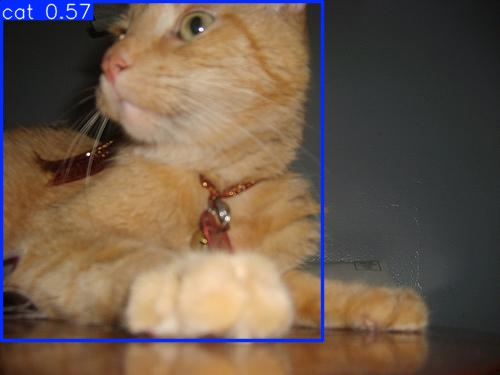

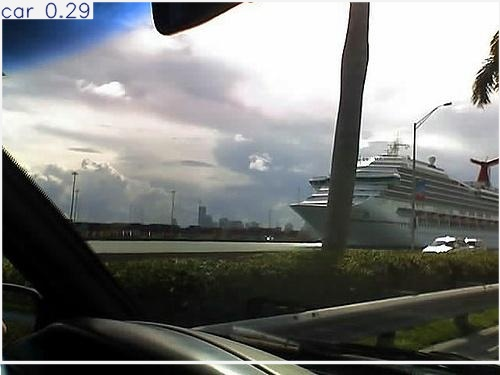

In [14]:
import glob, random
from IPython.display import Image, display

model_final = YOLO('content/runs/detect/voc_full_aug/weights/best.pt')
val_dir = os.path.join(base_dir, 'valid', 'images')
all_imgs = glob.glob(val_dir + '/*.jpg') + glob.glob(val_dir + '/*.png')
samples = random.sample(all_imgs, min(8, len(all_imgs)))

pred_results = model_final.predict(
    source=samples, save=True, conf=0.25, iou=0.45, name='predictions'
)

for r in pred_results[:4]:
    saved = Path(r.save_dir) / Path(r.path).name
    if saved.exists():
        display(Image(filename=str(saved), width=600))

In [15]:
# Save representative prediction images for the report
classes_wanted = {'car': None, 'dog': None, 'cat': None, 'bird': None}

for r in pred_results:
    if all(v is not None for v in classes_wanted.values()): break
    if r.boxes is None: continue
    detected = {model_final.names[int(b.cls[0])] for b in r.boxes}
    for cls in classes_wanted:
        if cls in detected and classes_wanted[cls] is None:
            saved = Path(r.save_dir) / Path(r.path).name
            if saved.exists():
                import shutil
                shutil.copy(saved, f'content/pred_{cls}.png')
                classes_wanted[cls] = f'content/pred_{cls}.png'

print('Saved:', {k: v for k, v in classes_wanted.items() if v})

Saved: {'car': 'content/pred_car.png', 'dog': 'content/pred_dog.png', 'cat': 'content/pred_cat.png', 'bird': 'content/pred_bird.png'}


## H. Results Summary

In [17]:
import numpy as np

print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)
print(f"\n{'Metric':<18} {'Model A':>10} {'Model B':>10} {'Gain':>8}")
print('-' * 48)
for name, a, b in [('mAP@50', ma50, mb50), ('mAP@50:95', ma5095, mb5095),
                   ('Precision', mprec, mbprec), ('Recall', mrec, mbrec)]:
    print(f'{name:<18} {a:>10.4f} {b:>10.4f} {a-b:>+8.4f}')

print(f'\nBest class:  {s_names[0]:<8}  AP@50 = {s_vals[0]:.4f}')
print(f'Worst class: {s_names[-1]:<8}  AP@50 = {s_vals[-1]:.4f}')

print('\nSize-based F1 (Model A):')
for r in res_a:
    print(f"  {r['Bucket']:<20} F1={r['F1']:.4f}  (P={r['Precision']:.4f}, R={r['Recall']:.4f})")

print('\nFiles saved:')
for f in ['content/class_dist.png', 'content/val_obj_size_dist.png',
          'content/model_comparison_metrics.png', 'content/fig2_perclass.png',
          'content/fig_size_comparison.png',
          'content/results_comparison.csv', 'content/size_performance.csv']:
    print(' ', f)
print('=' * 65)

RESULTS SUMMARY

Metric                Model A    Model B     Gain
------------------------------------------------
mAP@50                 0.8010     0.7574  +0.0435
mAP@50:95              0.6082     0.5553  +0.0529
Precision              0.8144     0.7743  +0.0401
Recall                 0.7211     0.6853  +0.0358

Best class:  cat       AP@50 = 0.8689
Worst class: bird      AP@50 = 0.7133

Size-based F1 (Model A):
  Small (<32x32)       F1=0.0000  (P=0.0000, R=0.0000)
  Medium (32-96px)     F1=0.0000  (P=0.0000, R=0.0000)
  Large (>96x96)       F1=0.0196  (P=0.0179, R=0.0217)

Files saved:
  content/class_dist.png
  content/val_obj_size_dist.png
  content/model_comparison_metrics.png
  content/fig2_perclass.png
  content/fig_size_comparison.png
  content/results_comparison.csv
  content/size_performance.csv


## I. Optimisation strategy

 This was based on our study of the paper by Rasheed and Zarkoosh on Optimized YOLOv8 for multi-scale object detection. This is written from scratch using the paper as a recipe. The motive of this exploratory or supplementary study was to focus on selective size detection -- as in some cases it is reasonable to target specific sizes while avoiding unnecessary computations.

In [ ]:
from pathlib import Path

size_counts_train = analyse_sizes(Path(base_dir) / "train" / "labels")

total = sum(size_counts_train.values())
small  = size_counts_train["Small (<32x32 px)"]
medium = size_counts_train["Medium (32-96 px)"]
large  = size_counts_train["Large (>96x96 px)"]

print("=" * 55)
print("OBJECT SIZE DISTRIBUTION — training set")
print("=" * 55)
for size, count in size_counts_train.items():
    pct = 100 * count / total
    bar = "#" * int(pct / 2)
    print(f"  {size:<22} {count:>5}  ({pct:5.1f}%)  {bar}")
print(f"\n  S={small}  M={medium}  L={large}")
print("=" * 55)

# ------------------------------------------------------------------
#   Options
#
#   "small"           only small objects dominate
#   "medium"          only medium objects dominate
#   "large"           only large objects dominate
#   "small-medium"    small and medium present, no large
#   "medium-large"    medium and large present, no small
#   "small-large"     small and large present, no medium
# ------------------------------------------------------------------
CHOSEN_VARIANT = "medium-large" 


In [ ]:
# Build the YAML

import yaml, os

NC = 5  # 

# Backbone 
BACKBONE = [
    [-1, 1, "Conv",  [64,  3, 2]],   # 0
    [-1, 1, "Conv",  [128, 3, 2]],   # 1
    [-1, 3, "C2f",   [128, True]],   # 2
    [-1, 1, "Conv",  [256, 3, 2]],   # 3
    [-1, 6, "C2f",   [256, True]],   # 4
    [-1, 1, "Conv",  [512, 3, 2]],   # 5
    [-1, 6, "C2f",   [512, True]],   # 6
    [-1, 1, "Conv",  [512, 3, 2]],   # 7
    [-1, 3, "C2f",   [512, True]],   # 8
    [-1, 1, "SPPF",  [512, 5]],      # 9
]

# Head

HEADS = {

    # keeps only Head 1 (small, 80x80)
    # Removes blocks 7,8 from backbone + most of neck
    # Upsamples SPPF output to match block 4 resolution
    "small": {
        "backbone": [
            [-1, 1, "Conv",  [64,  3, 2]],   # 0
            [-1, 1, "Conv",  [128, 3, 2]],   # 1
            [-1, 3, "C2f",   [128, True]],   # 2
            [-1, 1, "Conv",  [256, 3, 2]],   # 3
            [-1, 6, "C2f",   [256, True]],   # 4
            [-1, 1, "Conv",  [512, 3, 2]],   # 5
            [-1, 6, "C2f",   [512, True]],   # 6
            [-1, 1, "SPPF",  [512, 5]],      # 7   
        ],
        "head": [
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 8  upsample SPPF
            [[-1, 4], 1, "Concat",      [1]],                   # 9  concat with block 4
            [-1,      2, "C2f",         [256, False]],           # 10
            [[10],    1, "Detect",      [NC]],                   # 11 small head only
        ],
        "heads_desc": "1 head — small objects (80x80)",
        "removed":    "medium + large heads and their neck blocks",
    },

    # keeps only Head 2 (medium, 40x40)
    # Full backbone kept. Removes blocks 13-15 (small path) and 19-21 (large path)
    "medium": {
        "backbone": BACKBONE,
        "head": [
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 10
            [[-1, 6], 1, "Concat",      [1]],                   # 11
            [-1,      2, "C2f",         [512, False]],           # 12
            [4,       1, "Conv",        [256, 3, 2]],            # 13 from backbone 4
            [[-1,12], 1, "Concat",      [1]],                    # 14
            [-1,      2, "C2f",         [256, False]],           # 15
            [[15],    1, "Detect",      [NC]],                   # 16 medium head only
        ],
        "heads_desc": "1 head — medium objects (40x40)",
        "removed":    "small + large heads and their neck blocks",
    },

    # keeps only Head 3 (large, 20x20)
    # Full backbone. Removes all small+medium neck path
    "large": {
        "backbone": BACKBONE,
        "head": [
            [6,       1, "Conv",        [512, 3, 2]],            # 10 from backbone 6
            [[-1, 9], 1, "Concat",      [1]],                    # 11 concat with SPPF
            [-1,      2, "C2f",         [512, False]],           # 12
            [[12],    1, "Detect",      [NC]],                   # 13 large head only
        ],
        "heads_desc": "1 head — large objects (20x20)",
        "removed":    "small + medium heads and their neck blocks",
    },

    # keeps Heads 1+2 (small+medium)
    # Removes blocks 19-21 (large path) only
    "small-medium": {
        "backbone": BACKBONE,
        "head": [
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 10
            [[-1, 6], 1, "Concat",      [1]],                   # 11
            [-1,      2, "C2f",         [512, False]],           # 12
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 13
            [[-1, 4], 1, "Concat",      [1]],                   # 14
            [-1,      2, "C2f",         [256, False]],           # 15
            [4,       1, "Conv",        [256, 3, 2]],            # 16
            [[-1,12], 1, "Concat",      [1]],                   # 17
            [-1,      2, "C2f",         [512, False]],           # 18
            [[15,18], 1, "Detect",      [NC]],                   # 19 small+medium heads
        ],
        "heads_desc": "2 heads — small (80x80) + medium (40x40)",
        "removed":    "large head + blocks 19-21",
    },

    # keeps Heads 2+3 (medium+large)
    # Removes blocks 13-15 (small path). Block 16 rewired to backbone block 4
    "medium-large": {
        "backbone": BACKBONE,
        "head": [
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 10
            [[-1, 6], 1, "Concat",      [1]],                   # 11
            [-1,      2, "C2f",         [512, False]],           # 12
            [4,       1, "Conv",        [256, 3, 2]],            # 13 rewired from block 4
            [[-1,12], 1, "Concat",      [1]],                   # 14
            [-1,      2, "C2f",         [512, False]],           # 15
            [-1,      1, "Conv",        [512, 3, 2]],            # 16
            [[-1, 9], 1, "Concat",      [1]],                   # 17
            [-1,      2, "C2f",         [512, False]],           # 18
            [[15,18], 1, "Detect",      [NC]],                   # 19 medium+large heads
        ],
        "heads_desc": "2 heads — medium (40x40) + large (20x20)",
        "removed":    "small head + blocks 13-15 from original neck",
    },

    # keeps Heads 1+3 (small+large), skips medium
    # Removes blocks 15-17 (medium path). Block 19 rewired from block 12
    "small-large": {
        "backbone": BACKBONE,
        "head": [
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 10
            [[-1, 6], 1, "Concat",      [1]],                   # 11
            [-1,      2, "C2f",         [512, False]],           # 12
            [-1,      1, "nn.Upsample", [None, 2, "nearest"]],  # 13
            [[-1, 4], 1, "Concat",      [1]],                   # 14
            [-1,      2, "C2f",         [256, False]],           # 15 small head branch
            [12,      1, "Conv",        [512, 3, 2]],            # 16 rewired from block 12
            [[-1, 9], 1, "Concat",      [1]],                   # 17
            [-1,      2, "C2f",         [512, False]],           # 18 large head branch
            [[15,18], 1, "Detect",      [NC]],                   # 19 small+large heads
        ],
        "heads_desc": "2 heads — small (80x80) + large (20x20)",
        "removed":    "medium head + blocks 15-17 from original neck",
    },
}

# Build the chosen YAML

chosen = HEADS[CHOSEN_VARIANT]

model_yaml = {
    "nc": NC,
    "backbone": chosen["backbone"],
    "head": chosen["head"],
}

yaml_path = f"/content/yolov8_{CHOSEN_VARIANT.replace('-','_')}.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(model_yaml, f, default_flow_style=False, sort_keys=False)

print(f"YAML written  : {yaml_path}")
print(f"Variant       : YOLOv8-{CHOSEN_VARIANT}")
print(f"Architecture  : {chosen['heads_desc']}")
print(f"Removed       : {chosen['removed']}")
print(f"Classes       : {NC}")


In [ ]:
# Train Model C based on chosen variant
# Same epochs + augmentation as Model A so the comparison is fair. 

from ultralytics import YOLO

print(f"\nTRAINING MODEL C — YOLOv8-{CHOSEN_VARIANT}")
print(f"Architecture  : {chosen['heads_desc']}")
print("=" * 60)

model_c = YOLO(yaml_path)

results_c = model_c.train(
    data=DATA_YAML,
    epochs=20,
    imgsz=640,
    batch=16,
    name=f"voc_{CHOSEN_VARIANT.replace('-','_')}_paper",
    mosaic=1.0,       # same augmentation as Model A
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    fliplr=0.5,
    device=0,
    patience=15,
    save_period=10,
    plots=True,
    verbose=True,
)

print("\n" + "=" * 60)
print("MODEL C TRAINING COMPLETE")
print("=" * 60)

While this optimisation demonstrates a meaningful reduction in cost and inference time with minimal accuracy loss, its effectiveness remains data-dependent — A limitation we are still examining. For now we mainly focuss on the two previous main  Models.